In [28]:
import os
import cv2
import sys
import shutil
import glob
import numpy as np
import random
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import warnings
from rasterio.errors import NotGeoreferencedWarning

# ignore this specific rasterio warning
warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)

# look in parent directory for the src folder
sys.path.append('..')

# imports from the src folder
from src.converting import build_coco_json

In [24]:
# define image and mask tile directories
img_tiles_dir = "../data/tiled_cropped/images_fns"
mask_tiles_dir = "../data/tiled_cropped/masks_fns"

# Your new ML dataset folder
base_ml_dir = "../data/ml_dataset_cropped"

# geologically balanced split
splits = {
    "val": ["Chaos_E", "Chaos_jj"],
    "test": ["Chaos_D", "Chaos_H", "Chaos_ii"],
    "train": [
        "Chaos_A", "Chaos_B", "Chaos_C", "Chaos_Co", "Chaos_F", "Chaos_G", 
        "Chaos_I", "Chaos_aa", "Chaos_bb", "Chaos_dd", "Chaos_ee", "Chaos_ff", 
        "Chaos_gg", "Chaos_hh", "Chaos_kk"
    ]
}

# geologically balanced split (plates)
splits_plates = {
    "val": ["Chaos_I", "Chaos_jj"],
    "test": ["Chaos_ii", "Chaos_ee"],
    "train": [
        "Chaos_A", "Chaos_B", "Chaos_C", "Chaos_Co", "Chaos_D", "Chaos_E", 
        "Chaos_F", "Chaos_G", "Chaos_H", "Chaos_aa", "Chaos_bb", "Chaos_dd", 
        "Chaos_ff", "Chaos_gg", "Chaos_hh", "Chaos_kk"
    ]
}


splits_cropped = {
    "val": ["Chaos_hh", "Chaos_jj"],
    "test": ["Chaos_I", "Chaos_G", "Chaos_C", "Chaos_ff", "Chaos_F", "Chaos_kk", "Chaos_ee", "Chaos_H"],
    "train": ["Chaos_A", "Chaos_B", "Chaos_Co", "Chaos_D", "Chaos_E", "Chaos_aa", "Chaos_bb", "Chaos_dd", "Chaos_gg", "Chaos_ii"]
}

# create the folders
for split in splits_cropped.keys():
    os.makedirs(os.path.join(base_ml_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(base_ml_dir, split, "masks"), exist_ok=True)

# copy the files
all_imgs = glob.glob(os.path.join(img_tiles_dir, "*.jpg"))
print("Copying files to Train/Val/Test folders...")

count = 0
for img_path in all_imgs:
    filename = os.path.basename(img_path)
    
    # extract the region name
    parts = filename.split('_')
    region_name = f"{parts[0]}_{parts[1]}"
    
    # find which split this region belongs to
    target_split = None
    for split_name, region_list in splits.items():
        if region_name in region_list:
            target_split = split_name
            break
            
    if target_split:
        # copy Image
        shutil.copy(img_path, os.path.join(base_ml_dir, target_split, "images", filename))
        
        # copy Mask
        mask_filename = filename.replace('.jpg', '.tif')
        mask_path = os.path.join(mask_tiles_dir, mask_filename)
        if os.path.exists(mask_path):
            shutil.copy(mask_path, os.path.join(base_ml_dir, target_split, "masks", mask_filename))
        count += 1

print(f"Data splitting complete. Successfully moved {count} image/mask pairs.")

Copying files to Train/Val/Test folders...
Data splitting complete. Successfully moved 1380 image/mask pairs.


In [ ]:
# remove images that are not 256x256

for split in ['train', 'val']:
    img_dir = os.path.join(base_ml_dir, split, "images")
    mask_dir = os.path.join(base_ml_dir, split, "masks")
    
    all_jpgs = glob.glob(os.path.join(img_dir, "*.jpg"))
    deleted_count = 0
    
    for jpg_path in all_jpgs:
        # open the image and check its shape
        img = cv2.imread(jpg_path)
        if img is None:
            continue
            
        height, width = img.shape[:2]
        
        # if it is not a perfect 256x256 square, delete it and its mask
        if height != 256 or width != 256:
            os.remove(jpg_path)
            
            mask_path = os.path.join(mask_dir, os.path.basename(jpg_path).replace('.jpg', '.tif'))
            if os.path.exists(mask_path):
                os.remove(mask_path)
                
            deleted_count += 1
            
    print(f"Deleted {deleted_count} malformed edge tiles from the {split} set.")

Deleted 12 malformed edge tiles from the train set.
Deleted 6 malformed edge tiles from the val set.


In [30]:
# define direcrtory paths for training and validation tiled images and masks 
img_train_dir = "../data/ml_dataset_cropped/train/images"
img_val_dir = "../data/ml_dataset_cropped/val/images"
mask_train_dir = "../data/ml_dataset_cropped/train/masks"
mask_val_dir = "../data/ml_dataset_cropped/val/masks"

# define output JSON paths
out_json_train_path = "../data/ml_dataset_cropped/train/train_coco.json"
out_json_val_path = "../data/ml_dataset_cropped/val/val_coco.json"


# run file conversion function
build_coco_json(
    img_dir=img_train_dir,
    mask_dir=mask_train_dir,
    out_json_dir=out_json_train_path
)

build_coco_json(
    img_dir=img_val_dir,
    mask_dir=mask_val_dir,
    out_json_dir=out_json_val_path
)

Saved COCO JSON to ../data/ml_dataset_cropped/train/train_coco.json with 1170 images
and 13326 annotations.
Saved COCO JSON to ../data/ml_dataset_cropped/val/val_coco.json with 36 images
and 414 annotations.


JSON loaded successfully. Found 1170 images and 13326 blocks.


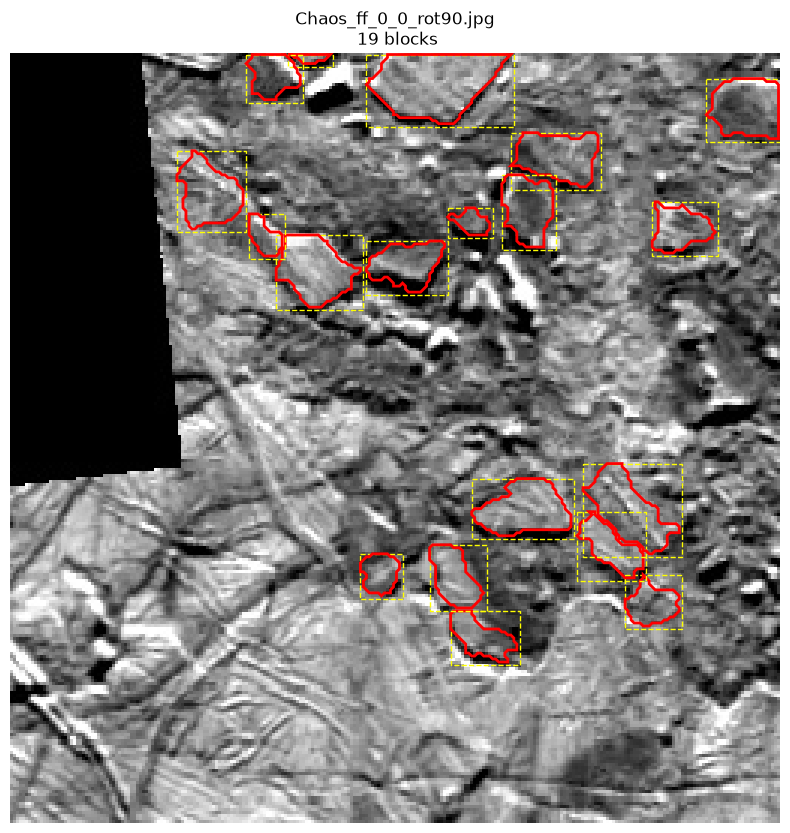

In [31]:
# verify that the file was converted to the COCO JSON format correctly
def verify_coco_json(json_path, img_dir):
    # load the JSON file
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # print progress message after JSON is loaded
    print(f"JSON loaded successfully. Found {len(coco_data['images'])} images and {len(coco_data['annotations'])} blocks.")

    # pick a random image that has annotations
    annotated_image_ids = [ann['image_id'] for ann in coco_data['annotations']]
    if not annotated_image_ids:
        print("No annotations found in the JSON")
        return
        
    random_image_id = random.choice(annotated_image_ids)
    
    # get the image file name
    img_info = next(img for img in coco_data['images'] if img['id'] == random_image_id)
    img_path = os.path.join(img_dir, img_info['file_name'])
    
    # get all annotations (blocks) for this image
    annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == random_image_id]
    
    # plot the image
    img = plt.imread(img_path)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    
    # draw the polygons and bounding boxes directly from the JSON coordinates
    for ann in annotations:
        # bounding box
        x, y, w, h = ann['bbox']
        rect = Rectangle((x, y), w, h, linewidth=1, edgecolor='yellow', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        
        # segmentation polygon
        # COCO segmentation is a flat list [x1, y1, x2, y2...] - reshape it to [(x1,y1), (x2,y2)...]
        flat_poly = ann['segmentation'][0]
        poly_points = np.array(flat_poly).reshape(-1, 2)
        polygon = Polygon(poly_points, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(polygon)
        
    ax.set_title(f"{img_info['file_name']}\n {len(annotations)} blocks")
    ax.axis('off')
    plt.show()

# run the v erification function
verify_coco_json(out_json_train_path, img_train_dir)